<a href="https://colab.research.google.com/github/MatiasHerrneder/sistemas-inteligentes-2026/blob/main/mlp-vs-cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Introducción

# 2. Carga y Exploración de Datos

### Configuracion inicial

In [35]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split


VALIDATION_SPLIT = 0.2

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# calcula media y std sobre todo el dataset
raw_dataset = datasets.FashionMNIST(root='./data', train=True, download=True,
                                     transform=transforms.ToTensor())

loader = DataLoader(raw_dataset, batch_size=512, shuffle=False)

mean = 0.0
std  = 0.0
n    = 0

for imgs, _ in loader:
    mean += imgs.mean(dim=[0, 2, 3])
    std  += imgs.std(dim=[0, 2, 3])
    n    += 1

mean /= n
std  /= n

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)) #type: ignore
])

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
# ])

train_full = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_set   = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

val_size   = int(VALIDATION_SPLIT * len(train_full))
train_size = len(train_full) - val_size

# split reproducible
train_set, val_set = random_split(
    train_full, [train_size, val_size],
    generator=torch.Generator().manual_seed(64))

train_loader = DataLoader(train_set, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False)

### Forma del tensor

In [36]:
sample_img, sample_label = train_full[0]
shape = tuple(sample_img.shape)
print(f"Channels: {shape[0]}\nHeight: {shape[1]}\nWidth: {shape[2]}")

Channels: 1
Height: 28
Width: 28


### Imagenes de ejemplo

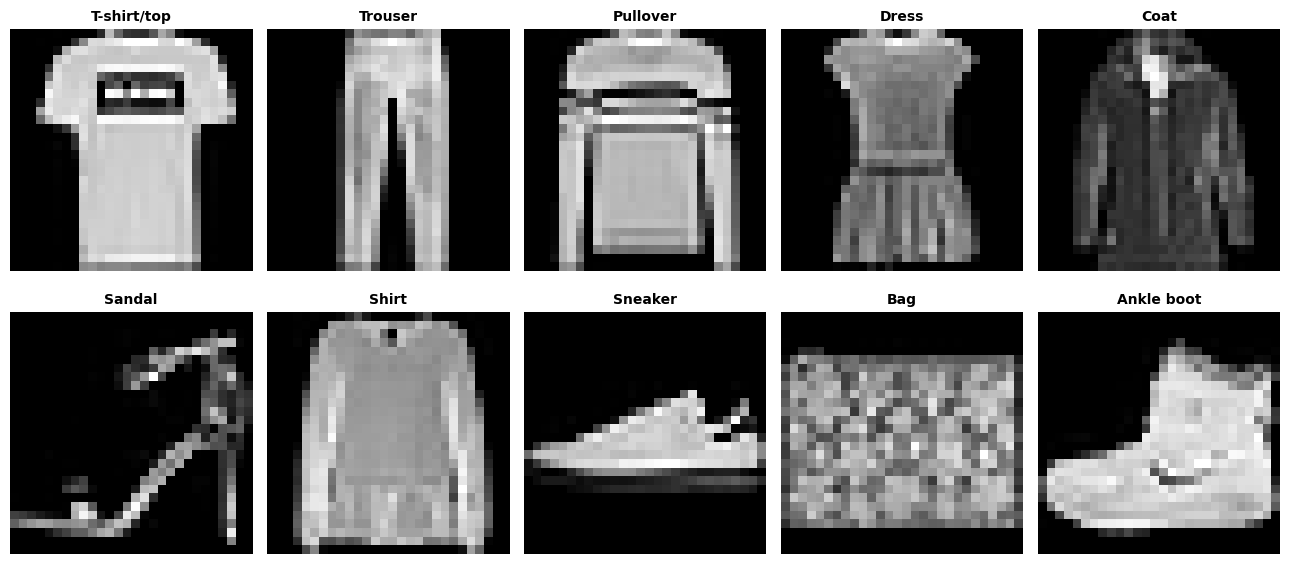

In [37]:
import matplotlib.pyplot as plt

def get_one_per_class(dataset, n_classes=10):
    found = {}
    for img, label in dataset:
        if label not in found:
            found[label] = img
        if len(found) == n_classes:
            break
    return [found[i] for i in range(n_classes)]

samples = get_one_per_class(train_full)

fig1, axes = plt.subplots(2, 5, figsize=(13, 6))

for ax, img, name in zip(axes.flat, samples, CLASS_NAMES):
    # Desnormalizar para mostrar [-1,1] -> [0,1]
    img_np = img.squeeze().numpy()
    img_np = (img_np * 0.5) + 0.5
    ax.imshow(img_np, cmap='gray')
    ax.set_title(name, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

### Distribucion de clases

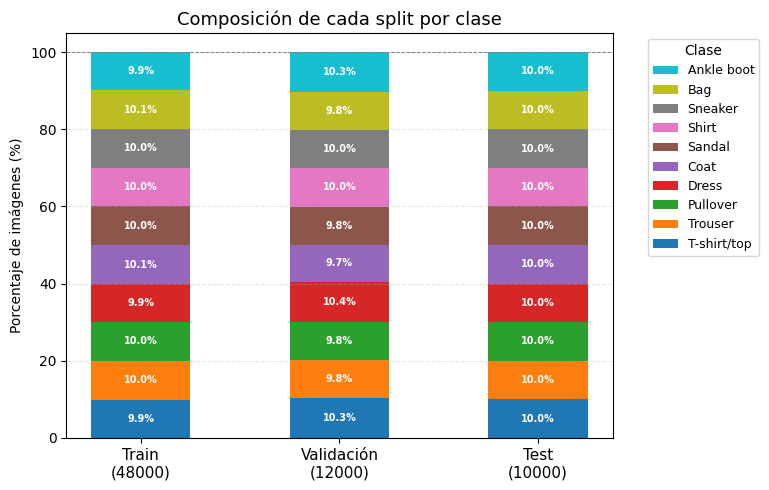

In [38]:
from collections import Counter
import numpy as np

def get_labels(subset):
    if hasattr(subset, 'dataset'):
        return [subset.dataset.targets[i].item() for i in subset.indices]
    else:
        return subset.targets.tolist()

train_labels = get_labels(train_set)
val_labels   = get_labels(val_set)
test_labels  = get_labels(test_set)

def label_counts(labels):
    c = Counter(labels)
    return [c[i] for i in range(10)]

splits = {
    f'Train\n({train_size})': label_counts(train_labels),
    f'Validación\n({val_size})': label_counts(val_labels),
    f'Test\n({len(test_set)})': label_counts(test_labels),
}

splits_pct = {
    name: np.array(counts) / sum(counts) * 100
    for name, counts in splits.items()
}

fig2, ax = plt.subplots(figsize=(8, 5))
bottom = np.zeros(3)
x = np.arange(3)

for i, class_name in enumerate(CLASS_NAMES):
    values = np.array([splits_pct[split][i] for split in splits_pct])
    bars = ax.bar(x, values, bottom=bottom, label=class_name, width=0.5)

    for j, (bar, val) in enumerate(zip(bars, values)):
        if val > 1.5:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + val / 2,
                f'{val:.1f}%',
                ha='center', va='center', fontsize=7, color='white', fontweight='bold'
            )
    bottom += values

ax.set_xticks(x)
ax.set_xticklabels(list(splits_pct.keys()), fontsize=11)
ax.set_ylabel("Porcentaje de imágenes (%)")
ax.set_title("Composición de cada split por clase", fontsize=13)
ax.set_ylim(0, 105)
ax.axhline(100, color='gray', linestyle='--', linewidth=0.7)
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[::-1], labels[::-1],
    loc='upper right', bbox_to_anchor=(1.28, 1), fontsize=9, title="Clase"
)
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### Rango de valores de los pixeles

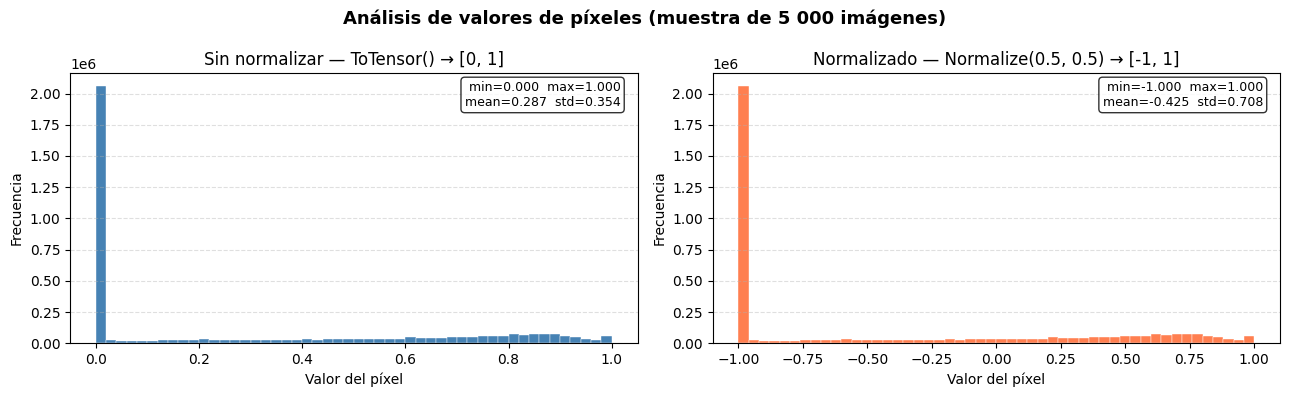

In [39]:
train_counts = label_counts(train_labels)

# calcula stats sobre píxeles RAW (sin normalizar) y normalizados
raw_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=False,
    transform=transforms.ToTensor()
)

# muestra aleatoria de 5000 imagenes
indices = torch.randperm(len(raw_dataset))[:5000]
sample_pixels_raw = torch.stack([raw_dataset[int(i)][0] for i in indices])
sample_pixels_norm = sample_pixels_raw * 2 - 1

fig3, axes3 = plt.subplots(1, 2, figsize=(13, 4))
fig3.suptitle("Análisis de valores de píxeles (muestra de 5 000 imágenes)", fontsize=13, fontweight='bold')

# histograma
ax = axes3[0]
flat_raw = sample_pixels_raw.flatten().numpy()
ax.hist(flat_raw, bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
ax.set_title("Sin normalizar — ToTensor() → [0, 1]")
ax.set_xlabel("Valor del píxel")
ax.set_ylabel("Frecuencia")
stats_raw = f"min={flat_raw.min():.3f}  max={flat_raw.max():.3f}\nmean={flat_raw.mean():.3f}  std={flat_raw.std():.3f}"
ax.text(0.97, 0.97, stats_raw, transform=ax.transAxes,
        va='top', ha='right', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax.grid(axis='y', linestyle='--', alpha=0.4)

# histograma normalizado
ax2 = axes3[1]
flat_norm = sample_pixels_norm.flatten().numpy()
ax2.hist(flat_norm, bins=50, color='coral', edgecolor='white', linewidth=0.3)
ax2.set_title("Normalizado — Normalize(0.5, 0.5) → [-1, 1]")
ax2.set_xlabel("Valor del píxel")
ax2.set_ylabel("Frecuencia")
stats_norm = f"min={flat_norm.min():.3f}  max={flat_norm.max():.3f}\nmean={flat_norm.mean():.3f}  std={flat_norm.std():.3f}"
ax2.text(0.97, 0.97, stats_norm, transform=ax2.transAxes,
         va='top', ha='right', fontsize=9,
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
ax2.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### Forma de las imagenes

In [40]:
shapes = set(raw_dataset[int(i)][0].shape for i in indices)
print(f"Formas únicas en el dataset: {shapes}")

Formas únicas en el dataset: {torch.Size([1, 28, 28])}


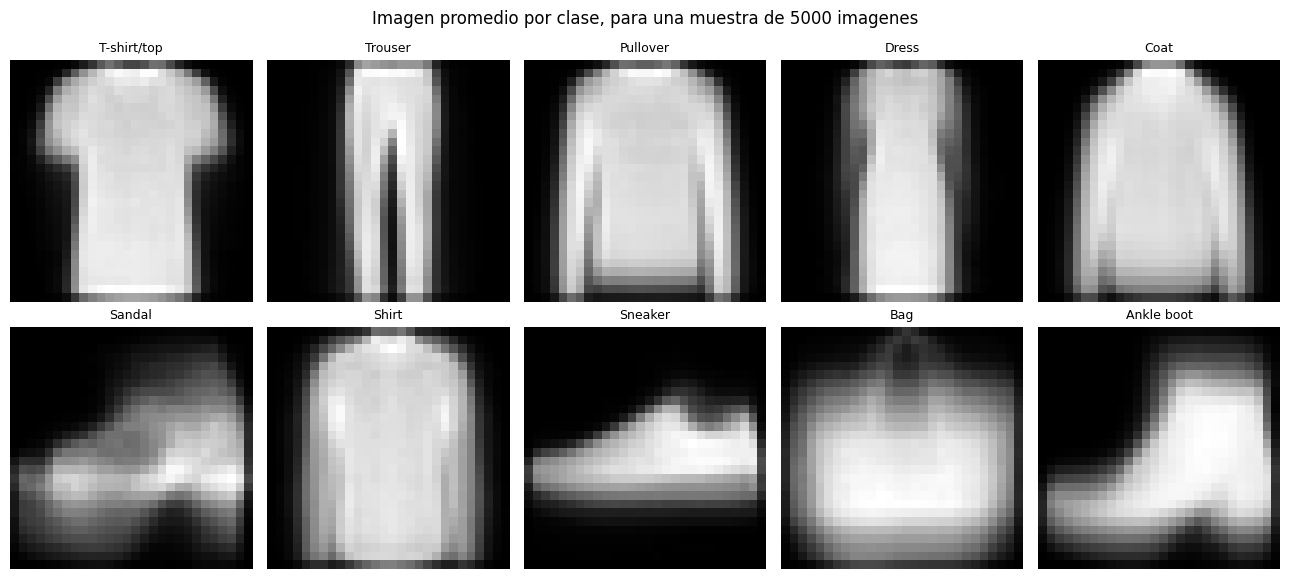

In [41]:
sample_size = min(len(raw_dataset), 5000)

fig, axes = plt.subplots(2, 5, figsize=(13, 6))
fig.suptitle(f"Imagen promedio por clase, para una muestra de {sample_size} imagenes")

for class_idx, ax in enumerate(axes.flat):
    imgs = [raw_dataset[int(i)][0] for i in range(sample_size)
            if raw_dataset[int(i)][1] == class_idx]
    mean_img = torch.stack(imgs).mean(dim=0).squeeze()
    ax.imshow(mean_img, cmap='gray')
    ax.set_title(CLASS_NAMES[class_idx], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

# 3. Preprocesamiento

### Normalizacion de las imagenes
Al inicio de la parte 2, ya se normalizaron las imagenes, para poder hacer correctamente los calculos del analisis, con valores de media y desvio:

In [42]:
print(f"Mean: {mean.item():.4f}") # type: ignore
print(f"Std:  {std.item():.4f}") # type: ignore

Mean: 0.2862
Std:  0.3530


### Aplanado de imagenes

In [43]:
transform_mlp = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(mean.item(),), std=(std.item(),)),  # type: ignore
    transforms.Lambda(lambda x: x.view(-1))
])

# Cargar datasets
train_full_mlp = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=False,
    transform=transform_mlp
)

test_set_mlp = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=False,
    transform=transform_mlp
)

# Split train/validation
val_size_mlp = int(VALIDATION_SPLIT * len(train_full_mlp))
train_size_mlp = len(train_full_mlp) - val_size_mlp

train_set_mlp, val_set_mlp = random_split(
    train_full_mlp,
    [train_size_mlp, val_size_mlp],
    generator=torch.Generator().manual_seed(64)
)

# DataLoaders
train_loader_mlp = DataLoader(train_set_mlp, batch_size=256, shuffle=True)
val_loader_mlp   = DataLoader(val_set_mlp, batch_size=256, shuffle=False)
test_loader_mlp  = DataLoader(test_set_mlp, batch_size=256, shuffle=False)

print("DataLoaders para MLP creados exitosamente.")
images, labels = next(iter(train_loader_mlp))
print(images.shape)

DataLoaders para MLP creados exitosamente.
torch.Size([256, 784])


# 4. Definición de los Modelos

## Modelo 1: MLP (MultiLayer Feedforward)

### Arquitectura MLP Base

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

class FashionMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 10)
        )

    def forward(self, x):
        return self.model(x)

### Crear modelo, loss y optimizador

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_mlp = FashionMLP().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_mlp.parameters(),
    lr=0.001
)

### Función de entrenamiento y evaluación

In [46]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

def evaluate(model, loader, criterion, device):
    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total

    return avg_loss, accuracy

### Entrenamiento del modelo

In [47]:
num_epochs = 15

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model_mlp,
        train_loader_mlp,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model_mlp,
        val_loader_mlp,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/15] Train Loss: 0.6252 | Train Acc: 0.7757 | Val Loss: 0.3933 | Val Acc: 0.8577
Epoch [2/15] Train Loss: 0.4166 | Train Acc: 0.8496 | Val Loss: 0.3511 | Val Acc: 0.8712
Epoch [3/15] Train Loss: 0.3763 | Train Acc: 0.8616 | Val Loss: 0.3315 | Val Acc: 0.8787
Epoch [4/15] Train Loss: 0.3488 | Train Acc: 0.8731 | Val Loss: 0.3170 | Val Acc: 0.8833
Epoch [5/15] Train Loss: 0.3297 | Train Acc: 0.8803 | Val Loss: 0.3108 | Val Acc: 0.8854
Epoch [6/15] Train Loss: 0.3161 | Train Acc: 0.8831 | Val Loss: 0.3173 | Val Acc: 0.8821
Epoch [7/15] Train Loss: 0.3029 | Train Acc: 0.8876 | Val Loss: 0.3107 | Val Acc: 0.8854
Epoch [8/15] Train Loss: 0.2907 | Train Acc: 0.8931 | Val Loss: 0.2993 | Val Acc: 0.8902
Epoch [9/15] Train Loss: 0.2836 | Train Acc: 0.8954 | Val Loss: 0.3064 | Val Acc: 0.8891
Epoch [10/15] Train Loss: 0.2727 | Train Acc: 0.8991 | Val Loss: 0.2912 | Val Acc: 0.8928
Epoch [11/15] Train Loss: 0.2683 | Train Acc: 0.9009 | Val Loss: 0.2950 | Val Acc: 0.8903
Epoch [12/15] Train

### Evaluar en test

              precision    recall  f1-score   support

 T-shirt/top     0.7928    0.9030    0.8443      1000
     Trouser     0.9848    0.9740    0.9794      1000
    Pullover     0.7988    0.8060    0.8024      1000
       Dress     0.8866    0.8910    0.8888      1000
        Coat     0.7820    0.8430    0.8114      1000
      Sandal     0.9765    0.9560    0.9661      1000
       Shirt     0.7893    0.6070    0.6863      1000
     Sneaker     0.9307    0.9670    0.9485      1000
         Bag     0.9739    0.9690    0.9714      1000
  Ankle boot     0.9599    0.9580    0.9590      1000

    accuracy                         0.8874     10000
   macro avg     0.8875    0.8874    0.8858     10000
weighted avg     0.8875    0.8874    0.8858     10000



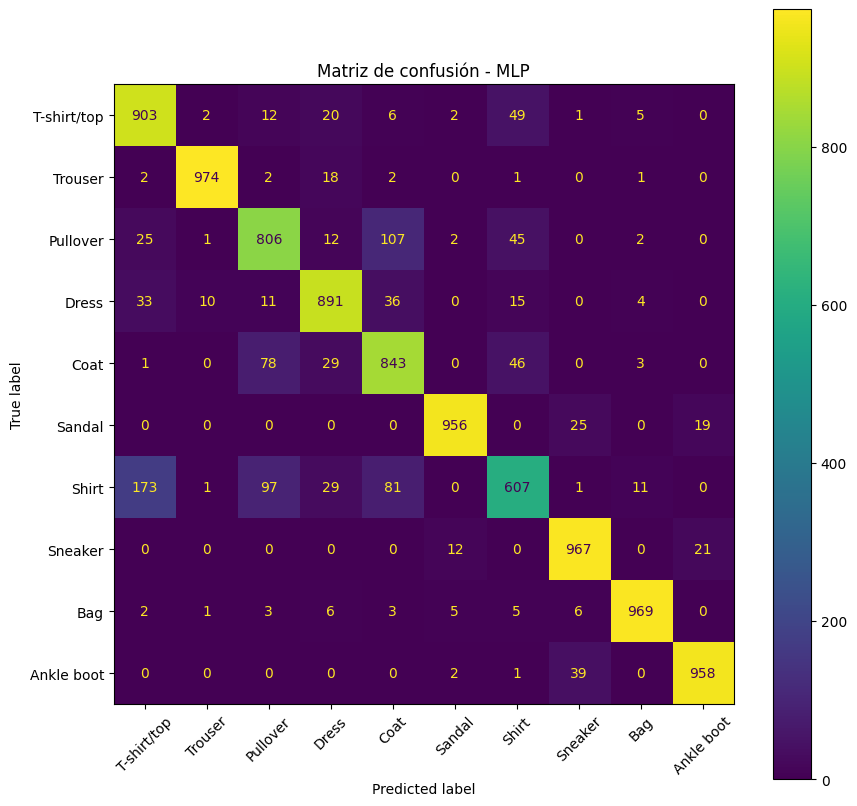

Test Loss: 0.3155
Test Accuracy: 0.8874


In [48]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

def get_predictions(model, loader, device):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_labels), np.array(all_preds)

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

y_true, y_pred = get_predictions(model_mlp, test_loader_mlp, device)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, xticks_rotation=45)
plt.title("Matriz de confusión - MLP")
plt.show()

test_loss, test_acc = evaluate(
    model_mlp,
    test_loader_mlp,
    criterion,
    device
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

## Modelo 2: CNN (Convolucional)

# 5. Experimentación

# 6. Discusión

# 7. Conclusiones y Trabajo Futuro